# **Tech Challenge - 13DTA - Grupo 14**


In [ ]:
#Carreagndo as Bibliotecas Utilizadas
#Panda/numpy/seaborn/matplotlib/plotly

# Faz a manipulação dos dados
import pandas as pd
import numpy as np

# Faz a visualização dos dados
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px


## **1. Objetivos do Projeto**
</br>
</br>

O desafio principal consiste na construção de um relatório executivo direcionado a investidores e acionistas do setor de e-commerce com base nos dados púclicos do Brazilian E-Commerce Public Dataset by Olist

</br>  

**Os objetivos específicos incluem:**
</br>

**Transformação de Dados:**
Converter dados transacionais do Brazilian E-Commerce Public Dataset by Olist em uma narrativa clara sobre desempenho comercial, eficiência logística e/ou satisfação do cliente
</br>

**Geração de Insights:**
Fornecer recomendações acionáveis e, se possível, previsões fundamentadas com base na análise
</br>

**Análise Multidimensional:**
Explorar trilhas analíticas como crescimento e receita, logística (SLA), comportamento de pagamento e satisfação do cliente (NPS)
</br>

**Comunicação Executiva:** Utilizar técnicas de storytelling para conectar os dados às decisões de investimento, utilizando uma linguagem acessível a diretores (sem termos técnicos)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **2. Entregas Obrigatórias**

Para a conclusão da atividade, iremos fornecer os seguintes itens:

**2.1. Link do Repositório no GitHub:** Contendo todos os códigos utilizados para o processamento e análise dos dados

**2.2. Link da Apresentação Executiva:** Material visual que suporte a narrativa e o storytelling desenvolvido

**2.3. Vídeo Executivo:** Duração máxima de 5 minutos, apresentado por pelo menos um integrante do grupo, focado em resultados e recomendações, utilizando linguagem executiva.

**2.4. Relatório Executivo Estruturado:** Documento contendo sumário, contexto, análise e conclusões

## **3. Descobrindo o Problema**
</br>

### **3.1. Análise das bases de dados**
</br>

Abaixo estão os principais pontos de conexão para relacionar os dados:
</br>
</br>


**Clientes / Pedidos**</br>
</br>
**order_id**
</br>

É a principal coluna para o fluxo de pedidos.
Ela conecta as tabelas de pedidos (orders), itens (order_items), pagamentos (order_payments) e avaliações (order_reviews).

</br>
</br>

**customer_id**
</br>

Conecta a tabela de clientes (customers) com a de pedidos (orders).
`Existe também o customer_unique_id na base de clientes, que serve para identificar o mesmo cliente em diferentes compras.`

</br>
</br>

**product_id**</br>
Conecta os itens do pedido (order_items) com a base de detalhes dos produtos (products).

</br>
</br>

**seller_id**</br>
Relaciona os vendedores (sellers) com os itens que foram vendidos em cada pedido (order_items).
</br>
</br>

**product_category_name**</br>
Serve para traduzir as categorias de português para inglês usando o arquivo product_category_name_translation.
</br>
</br>
</br>
**Geolocalização (ZIP Code)**</br>
customer_zip_code_prefix (em Clientes) ↔ geolocation_zip_code_prefix (em Geolocation).

</br>
seller_zip_code_prefix (em Vendedores) ↔ geolocation_zip_code_prefix (em Geolocation).

</br>
</br>
</br>

**Mapper**</br>

De (Tabela)   Para (Tabela)   Coluna de Ligação</br>
orders        order_items     order_id</br>
orders        customers       customer_id</br>
order_items   products        product_id</br>
order_items   sellers         seller_id</br>
products      translation     product_category_name</br>


In [ ]:
cf = pd.read_csv('/content/olist_customers_dataset.csv', sep=',')
cf.head(10)
cf_UF_CID = cf.groupby(['customer_state', 'customer_city']).size().reset_index(name='count')
cf_UF_CID.head()

,customer_state,customer_city,count
0,AC,brasileia,1
1,AC,cruzeiro do sul,3
2,AC,epitaciolandia,1
3,AC,manoel urbano,1
4,AC,porto acre,1


In [ ]:
import plotly.express as px

# Aggregate cf_UF_CID by customer_state to get total counts per state
customer_state_counts = cf_UF_CID.groupby('customer_state')['count'].sum().reset_index()

# Sort the states by count in descending order and select the top 10
top_10_states = customer_state_counts.sort_values(by='count', ascending=False).head(10)

# Create a bar chart using plotly.express
fig = px.bar(
    top_10_states,
    x='customer_state',
    y='count',
    title='Top 10 States by Customer Count',
    labels={'customer_state': 'State', 'count': 'Number of Customers'},
    color='customer_state'
)

# Display the plot
fig.show()

## **4. Sugestão das Análises**
</br>

Com as bases de clientes, pedidos e itens, podemos unir essas informações para entender o comportamento de vendas.
</br>


**Faturamento por Categoria:**</br>
Cruzando order_items, products e translation para ver quais segmentos trazem mais receita.
</br>
</br>

**Distribuição Geográfica:**</br>
Usando customers e orders para identificar de onde vêm os seus principais compradores.
</br>
</br>


**Ticket Médio por Estado:**</br>
Calculando quanto, em média, os clientes gastam dependendo da região.
</br>
</br>

Podemos também, ter os seguintes indicadores:</br>
</br>
**Identificar tendências:**</br>
Ver quais meses tiveram mais vendas.
</br>
</br>

**Análise de Logística:**</br>
Comparar o tempo de entrega estimado versus o tempo real.
</br>
</br>

**Satisfação:**</br>
Relacionar a nota das avaliações (review_score) com o tempo de entrega ou o valor do frete.

## **5. Abordagem em Logística e Satisfação dos clientes**
</br>
</br>


##### **5.1 Lead time entre compra, aprovação, postagem e entrega (Juninho)**
</br>


                              ANÁLISE DE LEAD TIME — OLIST E-COMMERCE

📂 Carregando dados...
   99,441 pedidos carregados.

⚙️  Calculando lead times...
   95,039 pedidos entregues válidos para análise.

📊 ETP — Estatísticas de Lead Time:

                    Etapa  Média (dias)  Mediana (dias)  Desvio Padrão  P10 (dias)  P90 (dias) % do Lead Total
  Compra → Aprovação (T1)          0.40            0.01           0.80        0.01        1.39            3.2%
Aprovação → Postagem (T2)          2.85            1.85           3.46        0.49        6.02           22.7%
  Postagem → Entrega (T3)          9.30            7.11           8.18        1.87       18.93           74.1%
         Total (T1+T2+T3)         12.55           10.27           9.01        4.18       23.13          100.0%

🖼️  Gerando dashboard executivo...

✅ Dashboard salvo em: leadtime_olist.png


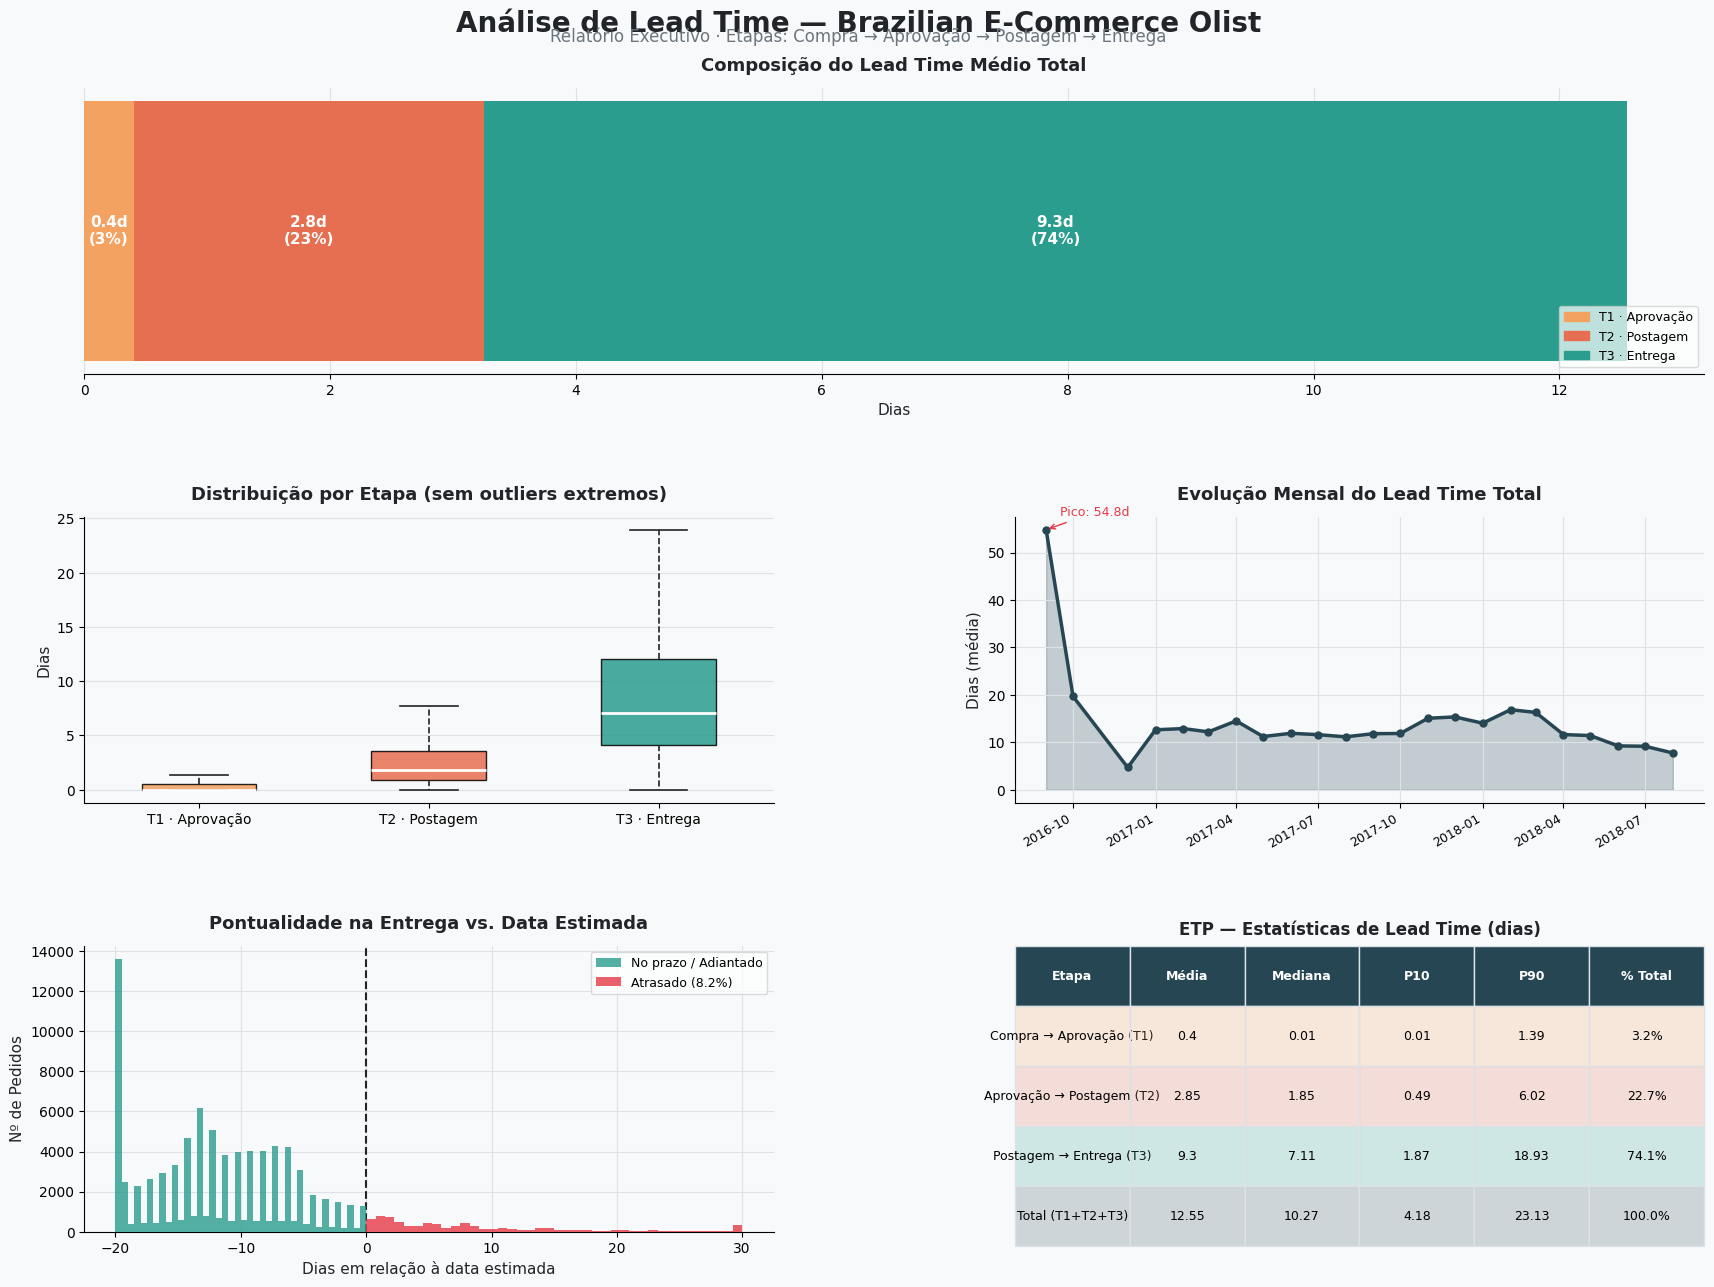

In [ ]:
"""
Análise de Lead Time - Lead Time entre Compra , Aprovação, Postagem e Entrega.

Este script realiza a análise de lead time entre as etapas:
compra → aprovação → postagem → entrega

"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────────────────────────────────────────────── #
#                                1. CARGA DOS DADOS                                        #
# ──────────────────────────────────────────────────────────────────────────────────────── #

def carregar_dados(caminho="./"):
    """
    Carrega os arquivos CSV do dataset Olist.
    Ajuste o caminho (caminho=) para onde seus CSVs estão salvos.
    """
    orders = pd.read_csv(f"{caminho}olist_orders_dataset.csv", parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ])
    return orders

# ──────────────────────────────────────────────────────────────────────────────────────── #
#                           2. ENGENHARIA DE FEATURES (ETP)                                #
# ──────────────────────────────────────────────────────────────────────────────────────── #

def calcular_lead_times(orders: pd.DataFrame) -> pd.DataFrame:
    """
    Calcula as etapas de lead time em horas e dias.

    Etapas:
        T1 – Compra → Aprovação      (aprovação do pagamento)
        T2 – Aprovação → Postagem    (preparação/despacho pelo seller)
        T3 – Postagem → Entrega      (trânsito logístico)
        T_total – Compra → Entrega   (experiência total do cliente)

    Também calcula:
        atraso_dias: diferença entre entrega real e estimada (+ = atrasado)
    """
    df = orders.copy()

    # Filtra apenas pedidos entregues com todas as datas preenchidas
    df = df[df["order_status"] == "delivered"].dropna(subset=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ])

    # Lead times em horas
    df["t1_aprovacao_h"]   = (df["order_approved_at"] - df["order_purchase_timestamp"]).dt.total_seconds() / 3600
    df["t2_postagem_h"]    = (df["order_delivered_carrier_date"] - df["order_approved_at"]).dt.total_seconds() / 3600
    df["t3_entrega_h"]     = (df["order_delivered_customer_date"] - df["order_delivered_carrier_date"]).dt.total_seconds() / 3600
    df["t_total_h"]        = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.total_seconds() / 3600

    # Lead times em dias (mais legível para executivos)
    df["t1_aprovacao_d"]   = df["t1_aprovacao_h"]  / 24
    df["t2_postagem_d"]    = df["t2_postagem_h"]   / 24
    df["t3_entrega_d"]     = df["t3_entrega_h"]    / 24
    df["t_total_d"]        = df["t_total_h"]       / 24

    # Atraso em relação à data estimada
    df["atraso_dias"] = (
        df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
    ).dt.total_seconds() / 86400

    # Remove outliers extremos (janela de 0 a 120 dias para total)
    df = df[
        (df["t_total_d"] > 0) & (df["t_total_d"] <= 120) &
        (df["t1_aprovacao_d"] >= 0) &
        (df["t2_postagem_d"] >= 0) &
        (df["t3_entrega_d"] >= 0)
    ]

    # Coluna ano-mês para análise temporal
    df["ano_mes"] = df["order_purchase_timestamp"].dt.to_period("M")

    return df


def calcular_estatisticas(df: pd.DataFrame) -> pd.DataFrame:
    """
    Retorna tabela ETP com estatísticas descritivas por etapa de lead time.
    ETP = Estatística de Tempo de Processamento
    """
    etapas = {
        "Compra → Aprovação (T1)":  "t1_aprovacao_d",
        "Aprovação → Postagem (T2)":"t2_postagem_d",
        "Postagem → Entrega (T3)":  "t3_entrega_d",
        "Total (T1+T2+T3)":         "t_total_d",
    }

    rows = []
    for nome, col in etapas.items():
        s = df[col]
        rows.append({
            "Etapa":             nome,
            "Média (dias)":      round(s.mean(), 2),
            "Mediana (dias)":    round(s.median(), 2),
            "Desvio Padrão":     round(s.std(), 2),
            "P10 (dias)":        round(s.quantile(0.10), 2),
            "P90 (dias)":        round(s.quantile(0.90), 2),
            "% do Lead Total":   f"{round(s.mean() / df['t_total_d'].mean() * 100, 1)}%"
        })

    etp = pd.DataFrame(rows)
    return etp

# ──────────────────────────────────────────────────────────────────────────────────────── #
#                             3. VISUALIZAÇÕES EXECUTIVAS                                  #
# ──────────────────────────────────────────────────────────────────────────────────────── #

CORES = {
    "t1": "#F4A261",   # Laranja – Aprovação
    "t2": "#E76F51",   # Vermelho – Postagem
    "t3": "#2A9D8F",   # Verde-azul – Entrega
    "total": "#264653",# Azul escuro – Total
    "fundo": "#F8F9FA",
    "grid": "#DEE2E6",
    "texto": "#212529",
    "accent": "#E63946",
}


def grafico_funil_etapas(df: pd.DataFrame, ax: plt.Axes):
    """Barras empilhadas horizontais mostrando composição do lead time."""
    medias = [
        df["t1_aprovacao_d"].mean(),
        df["t2_postagem_d"].mean(),
        df["t3_entrega_d"].mean(),
    ]
    labels = ["T1 · Aprovação", "T2 · Postagem", "T3 · Entrega"]
    cores  = [CORES["t1"], CORES["t2"], CORES["t3"]]

    total = sum(medias)
    left  = 0
    for i, (val, lab, cor) in enumerate(zip(medias, labels, cores)):
        ax.barh(0, val, left=left, color=cor, height=0.5, zorder=3)
        ax.text(left + val/2, 0, f"{val:.1f}d\n({val/total*100:.0f}%)",
                ha="center", va="center", fontsize=11, color="white",
                fontweight="bold")
        left += val

    ax.set_xlim(0, total * 1.05)
    ax.set_yticks([])
    ax.set_xlabel("Dias", fontsize=11, color=CORES["texto"])
    ax.set_title("Composição do Lead Time Médio Total", fontsize=13,
                 fontweight="bold", color=CORES["texto"], pad=12)
    ax.set_facecolor(CORES["fundo"])
    ax.grid(axis="x", color=CORES["grid"], zorder=0)
    ax.spines[["top","right","left"]].set_visible(False)

    legenda = [mpatches.Patch(color=c, label=l) for c, l in zip(cores, labels)]
    ax.legend(handles=legenda, loc="lower right", fontsize=9, framealpha=0.7)


def grafico_boxplot_etapas(df: pd.DataFrame, ax: plt.Axes):
    """Boxplot comparativo das 3 etapas."""
    dados  = [df["t1_aprovacao_d"], df["t2_postagem_d"], df["t3_entrega_d"]]
    labels = ["T1 · Aprovação", "T2 · Postagem", "T3 · Entrega"]
    cores  = [CORES["t1"], CORES["t2"], CORES["t3"]]

    bp = ax.boxplot(dados, vert=True, patch_artist=True,
                    showfliers=False, widths=0.5,
                    medianprops=dict(color="white", linewidth=2))

    for patch, cor in zip(bp["boxes"], cores):
        patch.set_facecolor(cor)
        patch.set_alpha(0.85)

    for whisker in bp["whiskers"]:
        whisker.set(color=CORES["texto"], linewidth=1.2, linestyle="--")
    for cap in bp["caps"]:
        cap.set(color=CORES["texto"], linewidth=1.2)

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel("Dias", fontsize=11, color=CORES["texto"])
    ax.set_title("Distribuição por Etapa (sem outliers extremos)",
                 fontsize=13, fontweight="bold", color=CORES["texto"], pad=12)
    ax.set_facecolor(CORES["fundo"])
    ax.grid(axis="y", color=CORES["grid"], zorder=0)
    ax.spines[["top","right"]].set_visible(False)


def grafico_evolucao_mensal(df: pd.DataFrame, ax: plt.Axes):
    """Evolução mensal do lead time total médio."""
    mensal = (
        df.groupby("ano_mes")["t_total_d"]
        .mean()
        .reset_index()
    )
    mensal["mes_dt"] = mensal["ano_mes"].dt.to_timestamp()

    ax.fill_between(mensal["mes_dt"], mensal["t_total_d"],
                    alpha=0.25, color=CORES["total"])
    ax.plot(mensal["mes_dt"], mensal["t_total_d"],
            color=CORES["total"], linewidth=2.5, marker="o", markersize=5)

    # Anotação do pico
    idx_max = mensal["t_total_d"].idxmax()
    ax.annotate(
        f'Pico: {mensal.loc[idx_max, "t_total_d"]:.1f}d',
        xy=(mensal.loc[idx_max, "mes_dt"], mensal.loc[idx_max, "t_total_d"]),
        xytext=(10, 10), textcoords="offset points",
        fontsize=9, color=CORES["accent"],
        arrowprops=dict(arrowstyle="->", color=CORES["accent"])
    )

    ax.set_ylabel("Dias (média)", fontsize=11, color=CORES["texto"])
    ax.set_title("Evolução Mensal do Lead Time Total",
                 fontsize=13, fontweight="bold", color=CORES["texto"], pad=12)
    ax.set_facecolor(CORES["fundo"])
    ax.grid(color=CORES["grid"], zorder=0)
    ax.spines[["top","right"]].set_visible(False)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=9)


def grafico_atraso_dist(df: pd.DataFrame, ax: plt.Axes):
    """Histograma de atraso em relação à data estimada."""
    atraso = df["atraso_dias"].clip(-20, 30)
    n_atrasados = (df["atraso_dias"] > 0).sum()
    pct_atrasados = n_atrasados / len(df) * 100

    ax.hist(atraso[atraso <= 0], bins=40, color=CORES["t3"],
            alpha=0.8, label="No prazo / Adiantado", zorder=3)
    ax.hist(atraso[atraso > 0],  bins=40, color=CORES["accent"],
            alpha=0.8, label=f"Atrasado ({pct_atrasados:.1f}%)", zorder=3)

    ax.axvline(0, color=CORES["texto"], linewidth=1.5, linestyle="--")
    ax.set_xlabel("Dias em relação à data estimada", fontsize=11, color=CORES["texto"])
    ax.set_ylabel("Nº de Pedidos", fontsize=11, color=CORES["texto"])
    ax.set_title("Pontualidade na Entrega vs. Data Estimada",
                 fontsize=13, fontweight="bold", color=CORES["texto"], pad=12)
    ax.legend(fontsize=9, framealpha=0.7)
    ax.set_facecolor(CORES["fundo"])
    ax.grid(color=CORES["grid"], zorder=0)
    ax.spines[["top","right"]].set_visible(False)


def gerar_dashboard(df: pd.DataFrame, etp: pd.DataFrame, salvar="leadtime_olist.png"):
    """Monta o dashboard executivo com 4 gráficos + tabela ETP."""
    fig = plt.figure(figsize=(18, 13), facecolor=CORES["fundo"])
    fig.suptitle(
        "Análise de Lead Time — Brazilian E-Commerce Olist",
        fontsize=20, fontweight="bold", color=CORES["texto"], y=0.98
    )
    fig.text(0.5, 0.955, "Relatório Executivo · Etapas: Compra → Aprovação → Postagem → Entrega",
             ha="center", fontsize=12, color="#6C757D")

    gs = gridspec.GridSpec(3, 2, figure=fig,
                           hspace=0.5, wspace=0.35,
                           left=0.07, right=0.97,
                           top=0.92, bottom=0.04)

    # Gráfico 1 – Funil
    ax1 = fig.add_subplot(gs[0, :])
    grafico_funil_etapas(df, ax1)

    # Gráfico 2 – Boxplot
    ax2 = fig.add_subplot(gs[1, 0])
    grafico_boxplot_etapas(df, ax2)

    # Gráfico 3 – Evolução mensal
    ax3 = fig.add_subplot(gs[1, 1])
    grafico_evolucao_mensal(df, ax3)

    # Gráfico 4 – Atraso
    ax4 = fig.add_subplot(gs[2, 0])
    grafico_atraso_dist(df, ax4)

    # Tabela ETP
    ax5 = fig.add_subplot(gs[2, 1])
    ax5.axis("off")
    ax5.set_title("ETP — Estatísticas de Lead Time (dias)",
                  fontsize=12, fontweight="bold", color=CORES["texto"], pad=8)

    col_labels = ["Etapa", "Média", "Mediana", "P10", "P90", "% Total"]
    table_data = etp[["Etapa","Média (dias)","Mediana (dias)","P10 (dias)","P90 (dias)","% do Lead Total"]].values

    tbl = ax5.table(
        cellText=table_data,
        colLabels=col_labels,
        cellLoc="center", loc="center",
        bbox=[0, -0.05, 1, 1.05]
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)

    cores_linha = [CORES["t1"], CORES["t2"], CORES["t3"], CORES["total"]]
    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor(CORES["grid"])
        if row == 0:
            cell.set_facecolor(CORES["total"])
            cell.set_text_props(color="white", fontweight="bold")
        elif 1 <= row <= 4:
            c = cores_linha[row - 1]
            cell.set_facecolor(c + "33")  # transparência
        else:
            cell.set_facecolor("white")

    plt.savefig(salvar, dpi=150, bbox_inches="tight",
                facecolor=CORES["fundo"])
    print(f"\n✅ Dashboard salvo em: {salvar}")
    plt.show()

# ──────────────────────────────────────────────────────────────────────────────────────── #
#                              4. EXECUÇÃO PRINCIPAL                                       #
# ──────────────────────────────────────────────────────────────────────────────────────── #

if __name__ == "__main__":
    print("=" * 100)
    print("                              ANÁLISE DE LEAD TIME — OLIST E-COMMERCE" )
    print("=" * 100)

# ── CARREGAMENTO ──────────────────────────────────────────
    # Ajuste o caminho para a pasta onde estão os CSVs do Olist
    CAMINHO_DADOS = "./"       # Ex: "/content/drive/MyDrive/olist/"

    print("\n📂 Carregando dados...")
    orders = carregar_dados(CAMINHO_DADOS)
    print(f"   {len(orders):,} pedidos carregados.")

    # ── PROCESSAMENTO ─────────────────────────────────────────
    print("\n⚙️  Calculando lead times...")
    df = calcular_lead_times(orders)
    print(f"   {len(df):,} pedidos entregues válidos para análise.")

    # ── ETP ───────────────────────────────────────────────────
    etp = calcular_estatisticas(df)
    print("\n📊 ETP — Estatísticas de Lead Time:\n")
    print(etp.to_string(index=False))

    # ── DASHBOARD ─────────────────────────────────────────────
    print("\n🖼️  Gerando dashboard executivo...")
    gerar_dashboard(df, etp, salvar="leadtime_olist.png")



##### **5.2 Correlação entre atrasos e review_score. (Sara)**
</br>


**Importação de bibliotecas e carregamento de dados** <br>
Tabelas necessárias para análise de correlação entre atrasos e review_score: <br>


*   Orders: contém as datas de entrega prevista e real de cada pedido
*   Reviews: contém as notas (review_score) dadas pelos clientes
*   Items: contém preço e frete, úteis para análises complementares







In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

orders = pd.read_csv("/content/olist_orders_dataset.csv")
reviews = pd.read_csv("/content/olist_order_reviews_dataset.csv")
items = pd.read_csv("/content/olist_order_items_dataset.csv")

**Conversão de datas e cálculo do atraso** <br>
As colunas de data chegam como texto (string). Primeiro, é preciso convertê-las para o tipo datetime do pandas, que permite operações matemáticas entre datas. Em seguida, criamos a variável central desta análise: 'atraso_dias', que mede a diferença entre a data de entrega real e a data prometida:
*   (menor que) 0: pedido chegou atrasado
*   = 0: pedido chegou exatamente no prazo
*   < 0: pedido chegou adiantado




In [ ]:
#date_cols armazena os nomes das duas colunas de data que precisam ser convertidas
date_cols = [
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

#faz a conversão de texto para datetime do pandas
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

orders['atraso_dias'] = (
    orders['order_delivered_customer_date'] -
    orders['order_estimated_delivery_date']
).dt.days

# Conferindo os tipos após a conversão
print(orders[date_cols].dtypes)

# Visualização de como ficou a nova coluna atraso_dias
print(orders[['order_delivered_customer_date',
              'order_estimated_delivery_date',
              'atraso_dias']].head())

# Estatísticas básicas do atraso (mín, máx, média)
print(orders['atraso_dias'].describe())

order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object
  order_delivered_customer_date order_estimated_delivery_date  atraso_dias
0           2017-10-10 21:25:13                    2017-10-18         -8.0
1           2018-08-07 15:27:45                    2018-08-13         -6.0
2           2018-08-17 18:06:29                    2018-09-04        -18.0
3           2017-12-02 00:28:42                    2017-12-15        -13.0
4           2018-02-16 18:17:02                    2018-02-26        -10.0
count    96476.000000
mean       -11.876881
std         10.183854
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: atraso_dias, dtype: float64


**Filtro de pedidos entregues e união com reviews** <br>
A análise foi restrita apenas a pedidos com status 'delivered', pois são os únicos que possuem data de entrega real preenchida e review válido. Pedidos cancelados, em trânsito ou sem entrega confirmada seriam ruído.

O merge une cada pedido à sua respectiva avaliação pelo campo order_id. O comando 'inner join' para manter apenas pedidos que possuem review registrado.

In [ ]:
#mantém apenas os pedidos entregues com data real e review válido
orders_entregues = orders[orders['order_status'] == 'delivered'].copy()

#une pedidos com suas respectivas notas pelo order_id
df = orders_entregues.merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='inner'
)

# Remove as linhas sem data de entrega real (apenas 8 casos)
df = df.dropna(subset=['atraso_dias', 'review_score'])

print(f"Base final: {len(df):,} pedidos")

Base final: 96,353 pedidos


**Classificação da situação de entrega** <br>
Foi criada uma variável categórica para agrupar os pedidos em três situações: pedido entregue adiantado, no prazo e atrasado. Isso permite a comparação entre a nota média de cada grupo e visualização de forma clara como o cumprimento (ou não) do prazo afeta a satisfação do cliente.

In [ ]:
#função que classifica cada pedido com base nos dias de atraso
def classificar_entrega(dias):
    if pd.isna(dias): return 'sem_info'
    elif dias < 0: return 'adiantado'
    elif dias == 0: return 'no_prazo'
    else: return 'atrasado'

#aplica a função em cada linha da coluna atraso_dias
df['situacao_entrega'] = df['atraso_dias'].apply(classificar_entrega)

#exibe a quantidade de pedidos em cada situação
print(df['situacao_entrega'].value_counts())

situacao_entrega
adiantado    88653
atrasado      6409
no_prazo      1291
Name: count, dtype: int64


**Análise estatística** <br>
Foi utilizada a correlação de Spearman (mais robusta que Pearson para dados ordinais como review_score) e a nota média por situação de entrega. Um coeficiente negativo confirma: quanto maior o atraso, menor a nota.

In [ ]:
#calcula a correlação de spearman entre o atraso e a nota do cliente
corr, pvalor = stats.spearmanr(df['atraso_dias'], df['review_score'])
print(f"Correlação de Spearman: {corr:.4f} (p-valor: {pvalor:.2e})")

#calcula a nota média agrupada por sutuação de entrega
media_por_situacao = df.groupby('situacao_entrega')['review_score'].mean().round(2)
print("\nNota média por situação de entrega:")
print(media_por_situacao)

Correlação de Spearman: -0.1762 (p-valor: 0.00e+00)

Nota média por situação de entrega:
situacao_entrega
adiantado    4.29
atrasado     2.27
no_prazo     4.03
Name: review_score, dtype: float64


**Visualizações** <br>
Foram gerados dois gráficos complementares: o Boxplot, que mostra a distribuição completa das notas por situação de entrega e o Barbplot, que destaca a diferença de nota média entre os três grupos. Juntos, eles tornam visível o impacto do atraso para o relatório executivo.


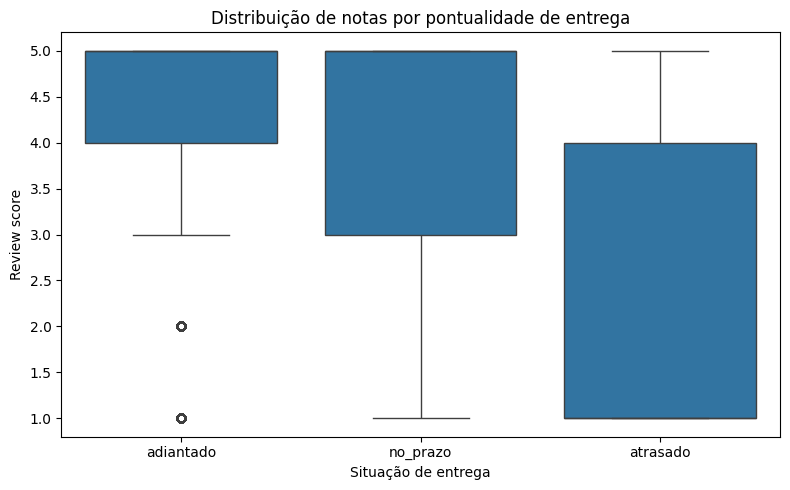

In [ ]:
#Boxplot
#define a ordem de exibição das categorias no eixo x
ordem = ['adiantado', 'no_prazo', 'atrasado']

fig, ax = plt.subplots(figsize=(8, 5))

#Gera o boxplot com a distribuição completa das notas por situação
sns.boxplot(data=df, x='situacao_entrega', y='review_score',
            order=ordem, ax=ax)

#Títulos e rótulos dos eixos
ax.set_title('Distribuição de notas por pontualidade de entrega')
ax.set_xlabel('Situação de entrega')
ax.set_ylabel('Review score')

#Ajusta o espaçamento para os elementos não se sorbeporem
plt.tight_layout()

#Exibe o gráfico
plt.show()

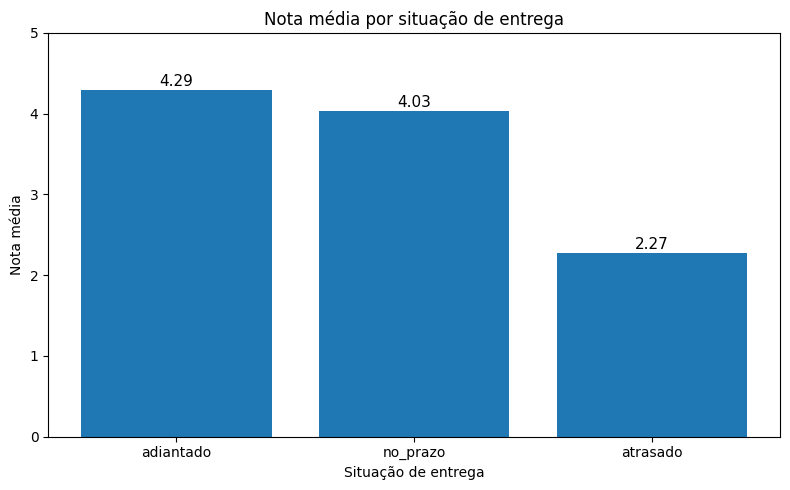

In [ ]:
#Barplot
fig, ax = plt.subplots(figsize=(8, 5))

#Calcula a nota média por situação e reordena conforme a ordem definida
medias = df.groupby('situacao_entrega')['review_score'].mean().reindex(ordem)

#Gera o barplot e define o eixo y de 0 a 5 (escala do review_score)
ax.bar(ordem, medias.values)
ax.set_ylim(0, 5)

#Títulos e rótulos dos eixos
ax.set_title('Nota média por situação de entrega')
ax.set_xlabel('Situação de entrega')
ax.set_ylabel('Nota média')

#Adiciona o valor numérico acima de cada barra
for i, v in enumerate(medias.values):
    ax.text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=11)

#Ajusta o espaçamento para os elementos não se sobreporem
plt.tight_layout()

#Exibe o gráfico
plt.show()


##### 5.3 Mapa de calor de desempenho por região. (Raul)
</br>



##### **5.4 Distribuição de review_score e temas recorrentes (Lucas).**
</br>


 Bloco 1: Imports e Carregamento da Base

 Nesta etapa, o objetivo é cruzar a fronteira entre os números operacionais e o sentimento real do consumidor.

Começamos com uma análise quantitativa da distribuição do `review_score`. O intuito é dimensionar a nossa base de clientes, entendendo a proporção exata entre os **Promotores** (que dão notas altas e são leais à marca) e os **Detratores** (que penalizam a marca com notas baixas), estabelecendo o tamanho do problema que precisamos investigar.

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
import re
from collections import Counter


nltk.download('stopwords')


reviews = pd.read_csv('/content/olist_order_reviews_dataset.csv')
print("Base de dados carregada com sucesso a partir da pasta /content/!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Base de dados carregada com sucesso a partir da pasta /content/!


Bloco 2: Gerar o Gráfico de Distribuição

Preparação dos Dados Qualitativos (Text Mining)


Como os textos livres contêm muito ruído estrutural, aplicamos técnicas de Processamento de Linguagem Natural (NLP). Filtramos apenas as avaliações que contêm mensagens escritas e realizamos uma "limpeza": removemos pontuações e *stopwords* (palavras vazias sem valor analítico, como 'e', 'de', 'produto', 'comprei'). Isso nos deixa apenas com o núcleo semântico da reclamação ou do elogio.

/tmp/ipykernel_18529/954629749.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=reviews, x='review_score', palette='viridis', ax=ax)


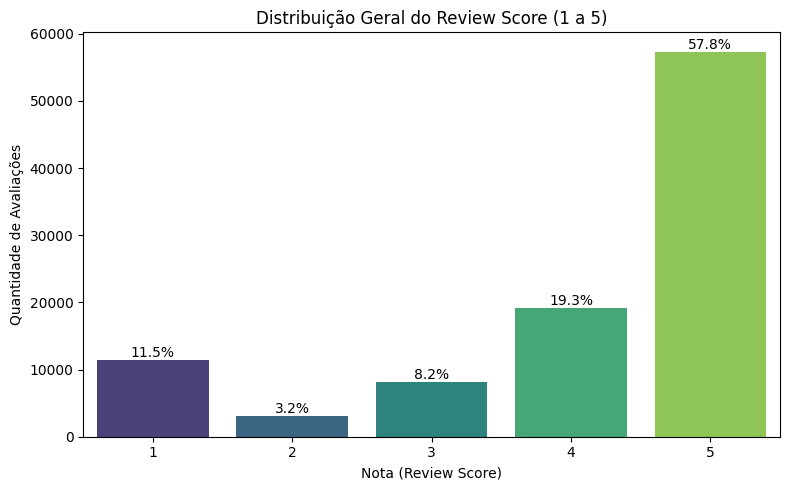

In [ ]:

# Calcular a distribuição em porcentagem
distribuicao_notas = reviews['review_score'].value_counts(normalize=True).sort_index() * 100

# Criar o gráfico de barras
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=reviews, x='review_score', palette='viridis', ax=ax)

ax.set_title('Distribuição Geral do Review Score (1 a 5)')
ax.set_xlabel('Nota (Review Score)')
ax.set_ylabel('Quantidade de Avaliações')

# Adicionar os percentuais em cima de cada barra
for p in ax.patches:
    altura = p.get_height()
    porcentagem = f'{(altura/len(reviews))*100:.1f}%'
    ax.annotate(porcentagem, (p.get_x() + p.get_width() / 2., altura),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

 Bloco 3: Preparação e Limpeza dos Textos

In [ ]:


reviews_com_texto = reviews.dropna(subset=['review_comment_message']).copy()


stop_words_pt = set(stopwords.words('portuguese'))
# Adicionando palavras muito comuns que não ajudam a entender o problema/solução
stop_words_pt.update(['produto', 'comprei', 'compra', 'veio', 'loja', 'entregue', 'chegou', 'recebi', 'prazo', 'dia', 'antes', 'recomendo'])

def limpar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r'[^a-záéíóúâêôãõç\s]', '', texto)
    palavras = texto.split()

    palavras_limpas = [p for p in palavras if p not in stop_words_pt and len(p) > 2]
    return palavras_limpas

# Aplicar a função para limpar os textos
print("Limpando os textos... Aguarde um momento.")
reviews_com_texto['palavras_limpas'] = reviews_com_texto['review_comment_message'].apply(limpar_texto)
print("Limpeza concluída com sucesso!")

Limpando os textos... Aguarde um momento.
Limpeza concluída com sucesso!


Bloco 4: Extração dos Temas Recorrentes

Com a base de textos higienizada, dividimos os clientes nos dois extremos de satisfação: **Detratores** (notas 1 e 2) e **Promotores** (nota 5).

Ao extrair e contabilizar os temas mais recorrentes em cada grupo, o objetivo é encontrar a causa raiz da insatisfação. Esta análise qualitativa serve como a "prova social" para validar as hipóteses levantadas nas análises de Lead Time e Atrasos (seções anteriores), demonstrando visualmente aos acionistas qual gargalo operacional tem o maior poder de destruição de valor e de marca.

In [ ]:

# Separar Detratores (notas 1 e 2) e Promotores (nota 5)
detratores = reviews_com_texto[reviews_com_texto['review_score'] <= 2]
promotores = reviews_com_texto[reviews_com_texto['review_score'] == 5]

# Função para contar as palavras mais frequentes
def contar_palavras(df_filtrado):
    todas_palavras = []
    for lista in df_filtrado['palavras_limpas']:
        todas_palavras.extend(lista)
    return Counter(todas_palavras).most_common(10)

top_detratores = contar_palavras(detratores)
top_promotores = contar_palavras(promotores)

print(" TOP 10 TEMAS - DETRATORES (Notas 1 e 2):")
for palavra, contagem in top_detratores:
    print(f"- {palavra}: {contagem} vezes")

print("\n TOP 10 TEMAS - PROMOTORES (Nota 5):")
for palavra, contagem in top_promotores:
    print(f"- {palavra}: {contagem} vezes")

 TOP 10 TEMAS - DETRATORES (Notas 1 e 2):
- entrega: 1393 vezes
- ainda: 1385 vezes
- nao: 935 vezes
- pedido: 779 vezes
- agora: 684 vezes
- apenas: 538 vezes
- nada: 508 vezes
- produtos: 508 vezes
- pois: 504 vezes
- site: 504 vezes

 TOP 10 TEMAS - PROMOTORES (Nota 5):
- entrega: 3618 vezes
- bom: 2896 vezes
- bem: 2179 vezes
- qualidade: 1713 vezes
- tudo: 1623 vezes
- excelente: 1588 vezes
- ótimo: 1501 vezes
- super: 1432 vezes
- rápida: 1123 vezes
- gostei: 1026 vezes


 Bloco 5: Visualização dos Temas Recorrentes

/tmp/ipykernel_18529/3010877558.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_detratores, y='Palavra', x='Frequência', ax=axes[0], palette='Reds_r')
/tmp/ipykernel_18529/3010877558.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_promotores, y='Palavra', x='Frequência', ax=axes[1], palette='Greens_r')


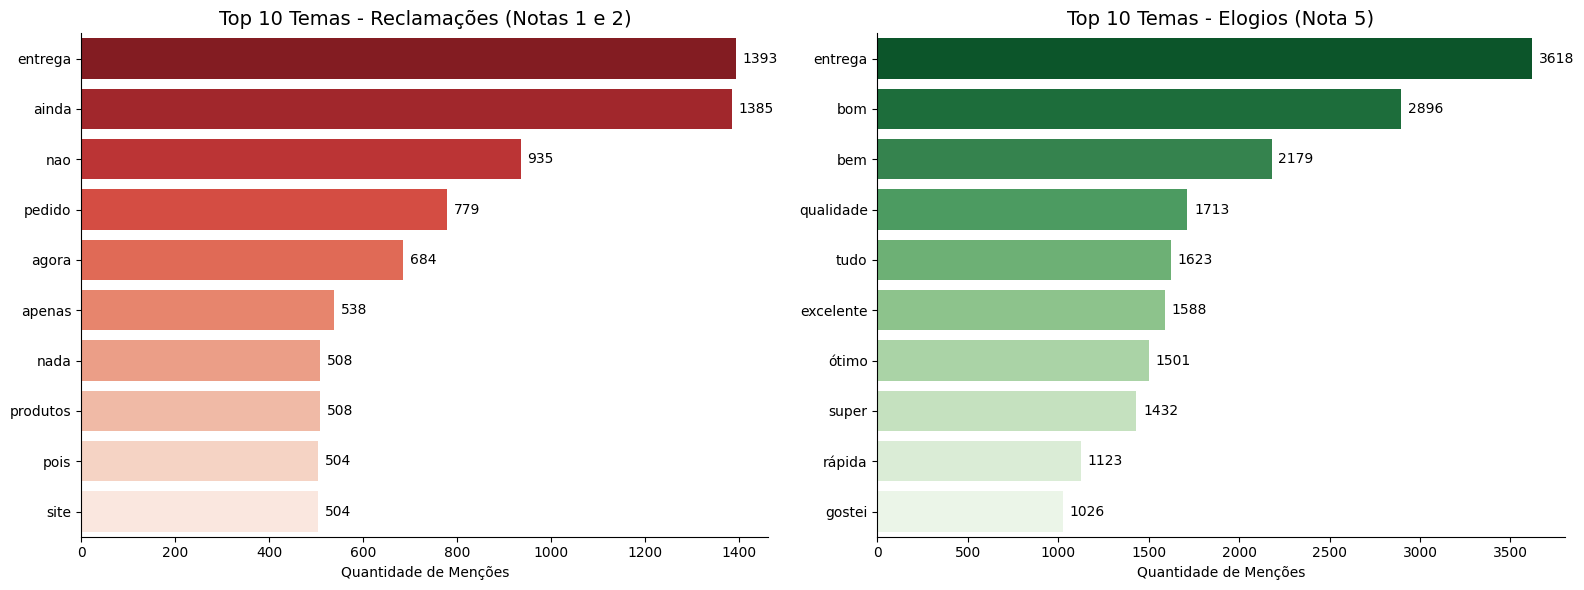

In [ ]:


df_detratores = pd.DataFrame(top_detratores, columns=['Palavra', 'Frequência'])
df_promotores = pd.DataFrame(top_promotores, columns=['Palavra', 'Frequência'])


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Detratores (Vermelho)
sns.barplot(data=df_detratores, y='Palavra', x='Frequência', ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 10 Temas - Reclamações (Notas 1 e 2)', fontsize=14)
axes[0].set_xlabel('Quantidade de Menções')
axes[0].set_ylabel('')

# Gráfico 2: Promotores (Verde)
sns.barplot(data=df_promotores, y='Palavra', x='Frequência', ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Temas - Elogios (Nota 5)', fontsize=14)
axes[1].set_xlabel('Quantidade de Menções')
axes[1].set_ylabel('')


for ax in axes:
    for p in ax.patches:
        ax.annotate(f'{int(p.get_width())}',
                    (p.get_width(), p.get_y() + p.get_height() / 2.),
                    ha='left', va='center',
                    xytext=(5, 0), textcoords='offset points', fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

##### **5.5 Drivers de satisfação: NPS e CSAT (André)**
</br>
</br>

##### NPS (Net Promoter Scores) - Identificar quem recomendaria ou não, e porquê.
Tabelas (order_reviews_dataset) - filtrar a coluna review_comment_title, separar as recomendações e não recomen e identificar as recomendações

##### CSAT (Customer Satisfaction Scores) - Identificar as experiências ruins.




## **6. Oportunidades e Recomendação (Vídeo)**
</br>
Logística
</br>
</br>
Satisfação de Clientes